### **13. Metric Evaluation for Clustering**

### **Lembar Kerja Praktikum:**
* Mata Kuliah :BDDM
* Pertemuan Ke : 25
* CPMK: Mahasiswa Mampu Menerapkan Metode Analisis Data (CPMK 21)
* Sub CPMK: Mahasiswa dapat mengevaluasi hasil pemodelan klustering (SCPMK 1682312)
* Indikator Keberhasilan: Mahasiswa dapat memvisualisasikan (grafik kerapatan cluster) hasil pemodelan cluster menggunakan bahasa pemrograman

### **Identitas Praktikan:**
* Nama: Yezha Amanando Rifky Zafian
* Nim: 23.11.5629
* Kelas: IF05

### **Tujuan Praktikum**
1. Mengidentifikasi kelayakan klastering menggunakan metrik tendensi klaster
2. Mengevaluasi kualitas klaster menggunakan validitas internal
3. Membandingkan hasil klaster dengan label referensi menggunakan validitas eksternal
4. Menarik kesimpulan analitis dari kombinasi ketiga metrik

### **Tendensi Klaster**
**1. Tendensi klaster** mengukur apakah suatu dataset memang memiliki struktur klaster yang **bermakna**, atau **hanya acak**. Dengan mengetahui tendensi cluster, maka kita akan mengetahui, "Apakah data ini layak untuk dilakukan klastering?".
Contoh metrik untuk melihat tendensi cluster:
* Hopkins Statistic
* Visual inspection (scatter plot, distance distribution)

**Hopkins Statistic**

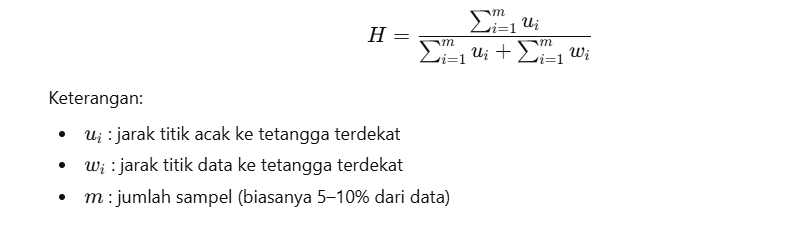



*   Jika nilai H≈ 0.5 maka Data acak (tidak ada klaster alami)
*   Jika nilai H< 0.3 maka Tendensi klaster kuat
*   Jika Nilai H	Interpretasi Nilai H:0.3 s/d 0.5 maka	Tendensi klaster lemah
*   Jika Nilai H> 0.7 maka pola tidak natural / grid-like



### **2. Validitas Internal**
**Validitas internal** menilai kualitas klaster berdasarkan **struktur data** itu sendiri, **tanpa label eksternal**. Prinsipnya menghitung kohesi(jarak intra cluster) dan separasi(jarak inter cluster)
contoh metrik:


*   Silhouette Score
*   Davies-Bouldin Index
*   Calinski-Harabasz Index



### **3. Validitas Eksternal**
**Validitas eksternal** mengukur kesesuaian hasil klaster dengan l**abel referensi (ground truth)**.<br>
Contoh metrik:
* Rand Index
* Adjusted Rand Index (ARI)
* Normalized Mutual Information (NMI)
<br>

Validitas eksternal digunakan ketika:

*   Dataset memiliki label (untuk evaluasi)
*   Perbandingan dengan klasifikasi atau anotasi ahli


**Melihat Tendensi Cluster dengan Hopkins Statistic**

In [1]:
import numpy as np
import pandas as pd

from sklearn import datasets
import matplotlib.pyplot as plt

from itertools import product

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
import random

In [2]:
#make_circles dapat digunakan untuk menghasilkan data dalam bentuk circle
X, y = datasets.make_circles(n_samples=500, noise=0.02, random_state=0)

In [3]:
#menampilkan 5 data teratas
#X adalah data yang membentuk circle
print('Nilai X : \n',X[:5])

#sedangkan y, adalah cluster dari data tersebut
print('\nCluster :\n',y[:5])

Nilai X : 
 [[-0.64935027  0.7694619 ]
 [ 0.75723522  0.08406494]
 [ 0.55074407  0.59177894]
 [ 0.14368733 -0.7838818 ]
 [ 0.45348142 -0.71992857]]

Cluster :
 [0 1 1 1 1]


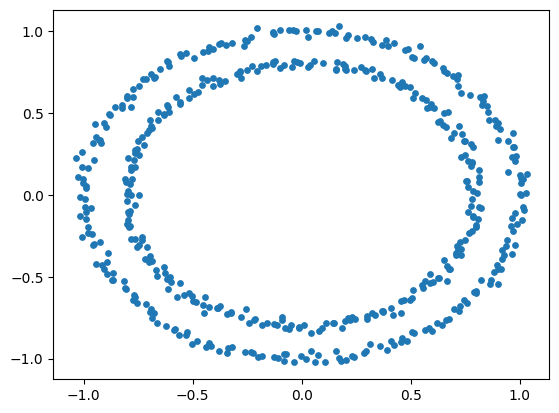

In [4]:
plt.scatter(X[:, 0], X[:, 1], s=15)
plt.show()

In [5]:
def hopkins_statistic(X):
    n, d = X.shape
    m = int(0.1 * n)

    nbrs = NearestNeighbors(n_neighbors=2).fit(X)
    rand_X = np.random.uniform(np.min(X, axis=0), np.max(X, axis=0), (m, d))

    u_dist, _ = nbrs.kneighbors(rand_X, 2)
    w_dist, _ = nbrs.kneighbors(X[random.sample(range(n), m)], 2)

    H = np.sum(u_dist[:,1]) / (np.sum(u_dist[:,1]) + np.sum(w_dist[:,1]))
    return H

In [6]:
H = hopkins_statistic(X)
print("Hopkins Statistic:", H)

Hopkins Statistic: 0.8877674937375163


Analisis:

Nilai Hopkins Statistic sebesar 0.8877 menunjukkan bahwa dataset tersebut memiliki pola pengelompokan (cluster tendency) yang sangat kuat,nilai yang mendekati 1,datasetnya sangat valid untuk diproses menggunakan algoritma clustering.

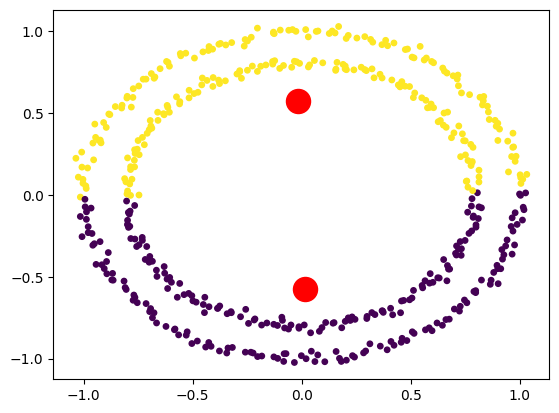

In [7]:
kmeans_cluster = KMeans(n_clusters=2, init='k-means++', max_iter=300,
                n_init=10, random_state=0)
kmeans_result = kmeans_cluster.fit_predict(X)

plt.scatter(X[:,0], X[:,1], s=15, c=kmeans_result)
plt.scatter(kmeans_cluster.cluster_centers_[:, 0],
            kmeans_cluster.cluster_centers_[:, 1],
            s=300, c='red')
plt.show()

In [8]:
#create eps and min_samples combination
eps_values = np.arange(0.02,0.3,0.01)
min_samples = np.arange(2,5)
dbscan_params = list(product(eps_values, min_samples))

In [9]:
#list contains looping result
no_of_clusters = []
epsvalues = []
min_samp = []

#itarate over parameter combinations
for p in dbscan_params:
    #create a dbscan cluster based on a combination of parameters
    dbscan_cluster = DBSCAN(eps=p[0], min_samples=p[1]).fit(X)

    #no of cluster must be > 1, so if cluster <= 1 then pass to next iteration
    if len(np.unique(dbscan_cluster.labels_)) <= 1 :
      pass
    else :
      no_of_clusters.append(len(np.unique(dbscan_cluster.labels_)))

    #append values to list
    epsvalues.append(p[0])
    min_samp.append(p[1])

In [10]:
#create a dataframe based on the iteration results
eps_min = list(zip(no_of_clusters, epsvalues, min_samp))
eps_min_df = pd.DataFrame(eps_min,
                          columns=['no_of_clusters',
                                   'epsilon_values', 'minimum_points'])
eps_min_df.head()

,no_of_clusters,epsilon_values,minimum_points
0,99,0.02,2
1,23,0.02,3
2,2,0.02,4
3,141,0.03,2
4,64,0.03,3


In [11]:
eps_min_df[eps_min_df['no_of_clusters']==2]

,no_of_clusters,epsilon_values,minimum_points
2,2,0.02,4
18,2,0.08,2
19,2,0.08,3
20,2,0.08,4
21,2,0.09,2
22,2,0.09,3
23,2,0.09,4
24,2,0.10,2
25,2,0.10,3
26,2,0.10,4


In [12]:
dbscan_cluster = DBSCAN(eps=0.08,min_samples=2)
dbscan_cluster.fit(X)

dbscan_result = dbscan_cluster.labels_

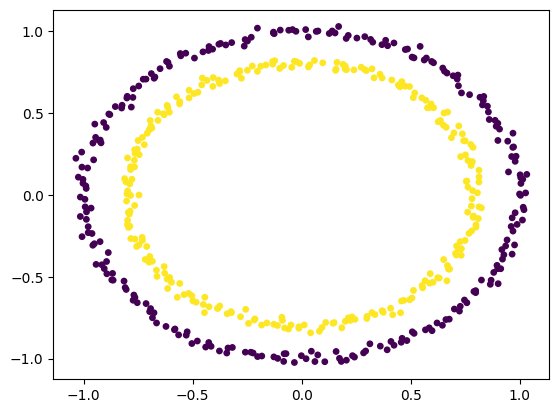

In [13]:
plt.scatter(X[:,0], X[:,1], s=15, c=dbscan_result)
plt.show()

**validitas internal**

In [14]:
dbi_kmeans = davies_bouldin_score(X, kmeans_result)
dbi_dbscan = davies_bouldin_score(X, dbscan_result)

print('DBI KMeans Score : ',dbi_kmeans)
print('DBI DBSCAN Score : ',dbi_dbscan)

DBI KMeans Score :  1.1405252293349897
DBI DBSCAN Score :  690.8008186438688


In [15]:
sil_kmeans = silhouette_score(X, kmeans_result)
sil_dbscan = silhouette_score(X, dbscan_result)

print('Silhouette Score KMeans Score : ',sil_kmeans)
print('Silhouette Score DBSCAN Score : ',sil_dbscan)

Silhouette Score KMeans Score :  0.4012044555844719
Silhouette Score DBSCAN Score :  0.018394551918884203


Kmens lebih bagus karena Silhautte Score lebih tinggi

**Validitas Eksternal**

In [ ]:
#sklearn.metrics.rand_score(labels_true, labels_pred)
from sklearn.metrics import rand_score

rand_score_Kmeans=rand_score(y, kmeans_result)
rand_score_dbscan=rand_score(y, dbscan_result)

print('Rand Score of KMeans : ',rand_score_Kmeans)
print('Rand Score of DBSCAN : ',rand_score_dbscan)

Rand Score of KMeans :  0.4990300601202405
Rand Score of DBSCAN :  1.0


In [ ]:
from sklearn.metrics import adjusted_rand_score

ari_kmeans = adjusted_rand_score(y, kmeans_result)
ari_dbscore = adjusted_rand_score(y, dbscan_result)
print('Adjusted Rand Score of KMeans : ',ari_kmeans)
print('Adjusted Rand Score of DBSCAN : ',ari_dbscore)

Adjusted Rand Score of KMeans :  -0.0019439036144578313
Adjusted Rand Score of DBSCAN :  1.0


DBSCAN lebih bagus

Analisis:

Hasil bisa berbeda dikarenakan Kmens unggul pada metrik internal,sedangkan DBscan menang telak pada metrik eksternal.Tetapi meskipun kmens terlihat lebih baik digambar 1,menurut saya DBscan adalah algoritma yang benar karena mampu mengikuti struktur kepadatan lingkaran,sementara kmens gagal meisahkan bentuk non-linier.

link dataset iris: https://drive.google.com/file/d/1vU087L8TnJAeumCuMISfYZExHTSPDm7Z/view?usp=sharing

In [16]:
df = pd.read_csv('/content/Iris.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


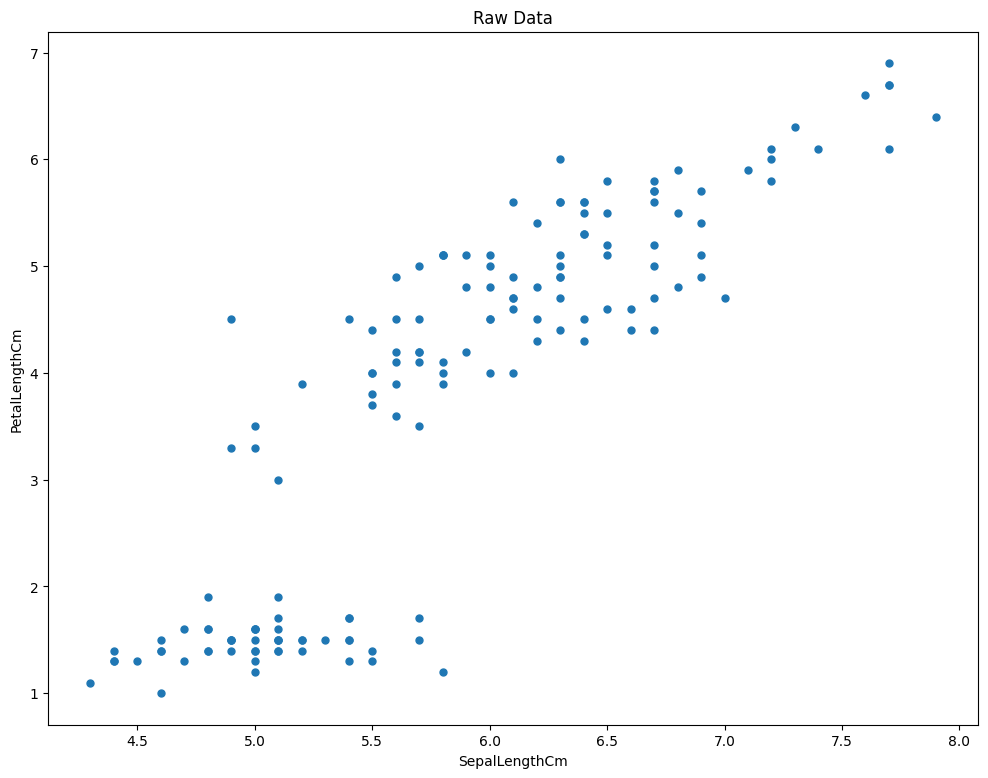

In [17]:
plt.figure(figsize=(12,9))
plt.scatter(df['SepalLengthCm'], df['PetalLengthCm'], s = 25) #Point size is 25
plt.title('Raw Data')
plt.xlabel('SepalLengthCm')
plt.ylabel('PetalLengthCm')
plt.show()

In [18]:
X = np.array(df.iloc[:,[1,3]])

In [19]:
H = hopkins_statistic(X)
print("Hopkins Statistic:", H)

Hopkins Statistic: 0.8619704013601087


clustering menggunakan k-means, dengan jumlah cluster 2

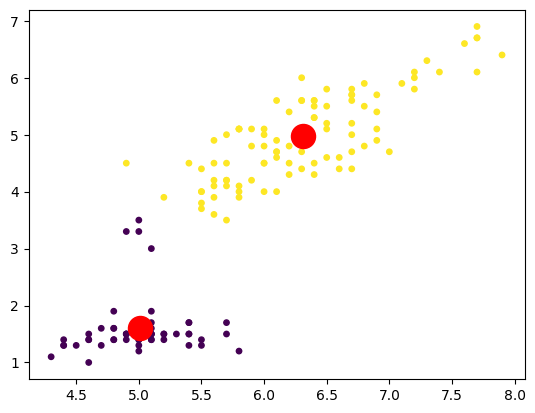

In [21]:
kmeans_cluster = KMeans(n_clusters=2, init='k-means++', max_iter=300,
                n_init=10, random_state=0)
kmeans_result = kmeans_cluster.fit_predict(X)

plt.scatter(X[:,0], X[:,1], s=15, c=kmeans_result)
plt.scatter(kmeans_cluster.cluster_centers_[:, 0],
            kmeans_cluster.cluster_centers_[:, 1],
            s=300, c='red')
plt.show()

In [22]:
eps_values_iris = np.arange(0.1, 2.0, 0.1)
min_samples_iris = np.arange(2, 6)
dbscan_params_iris = list(product(eps_values_iris, min_samples_iris))

no_of_clusters_iris = []
epsvalues_iris = []
min_samp_iris = []

for p in dbscan_params_iris:

    dbscan_cluster_iris = DBSCAN(eps=p[0], min_samples=p[1]).fit(X)

    if len(np.unique(dbscan_cluster_iris.labels_)) <= 1 :
      pass
    else :
      no_of_clusters_iris.append(len(np.unique(dbscan_cluster_iris.labels_)))


    epsvalues_iris.append(p[0])
    min_samp_iris.append(p[1])

eps_min_df_iris = pd.DataFrame(list(zip(no_of_clusters_iris, epsvalues_iris, min_samp_iris)),
                          columns=['no_of_clusters', 'epsilon_values', 'minimum_points'])

print("DBSCAN parameter search for Iris dataset:")
print(eps_min_df_iris[eps_min_df_iris['no_of_clusters'] == 2])

DBSCAN parameter search for Iris dataset:
    no_of_clusters  epsilon_values  minimum_points
16               2             0.5               2
17               2             0.5               3
18               2             0.5               4
20               2             0.6               2
21               2             0.6               3
22               2             0.6               4
23               2             0.6               5
24               2             0.7               2
25               2             0.7               3
26               2             0.7               4
27               2             0.7               5
28               2             0.8               2
29               2             0.8               3
30               2             0.8               4
31               2             0.8               5
32               2             0.9               2
33               2             0.9               3
34               2             0.9      

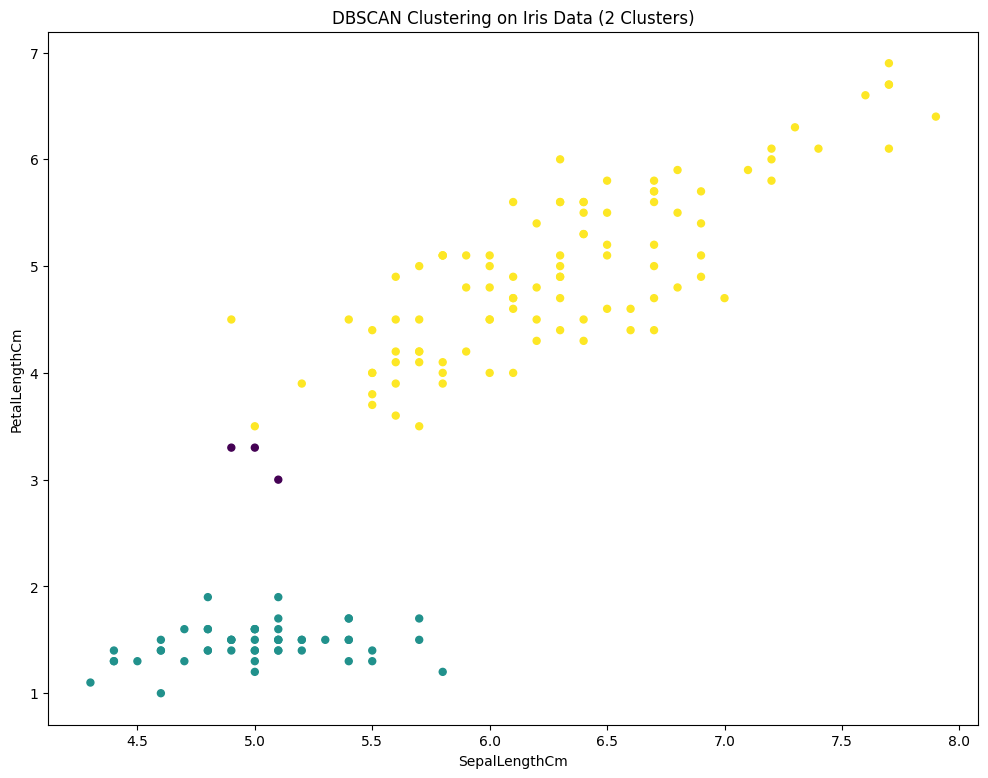

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,DBSCAN_Cluster
0,1,5.1,3.5,1.4,0.2,Iris-setosa,0
1,2,4.9,3.0,1.4,0.2,Iris-setosa,0
2,3,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5,5.0,3.6,1.4,0.2,Iris-setosa,0


In [23]:
dbscan_cluster_iris = DBSCAN(eps=0.5, min_samples=5)
dbscan_cluster_iris.fit(X)

df['DBSCAN_Cluster'] = dbscan_cluster_iris.labels_

plt.figure(figsize=(12,9))
plt.scatter(X[:,0], X[:,1], s=25, c=df['DBSCAN_Cluster'])
plt.title('DBSCAN Clustering on Iris Data (2 Clusters)')
plt.xlabel('SepalLengthCm')
plt.ylabel('PetalLengthCm')
plt.show()

df.head()

In [26]:
df['KMeans_Cluster'] = kmeans_result
dbi_kmeans_iris = davies_bouldin_score(X, df['KMeans_Cluster'])
dbi_dbscan_iris = davies_bouldin_score(X, df['DBSCAN_Cluster'])

sil_kmeans_iris = silhouette_score(X, df['KMeans_Cluster'])
sil_dbscan_iris = silhouette_score(X, df['DBSCAN_Cluster'])

print('Validasi Internal:')
print('DBI KMeans Score    : ', dbi_kmeans_iris)
print('DBI DBSCAN Score    : ', dbi_dbscan_iris)
print('Silhouette Score KMeans  : ', sil_kmeans_iris)
print('Silhouette Score DBSCAN : ', sil_dbscan_iris)

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import rand_score, adjusted_rand_score
le = LabelEncoder()
y_true_iris = le.fit_transform(df['Species'])

rand_score_Kmeans_iris = rand_score(y_true_iris, df['KMeans_Cluster'])
rand_score_dbscan_iris = rand_score(y_true_iris, df['DBSCAN_Cluster'])

ari_kmeans_iris = adjusted_rand_score(y_true_iris, df['KMeans_Cluster'])
ari_dbscore_iris = adjusted_rand_score(y_true_iris, df['DBSCAN_Cluster'])

print('\nValidasi eksternal:')
print('Rand Score of KMeans      : ', rand_score_Kmeans_iris)
print('Rand Score of DBSCAN      : ', rand_score_dbscan_iris)
print('Adjusted Rand Score of KMeans  : ', ari_kmeans_iris)
print('Adjusted Rand Score of DBSCAN  : ', ari_dbscore_iris)

Validasi Internal:
DBI KMeans Score    :  0.3554285643215244
DBI DBSCAN Score    :  0.41181679544839717
Silhouette Score KMeans  :  0.7096825580716465
Silhouette Score DBSCAN :  0.5011649528054901

Validasi eksternal:
Rand Score of KMeans      :  0.759821029082774
Rand Score of DBSCAN      :  0.7770917225950783
Adjusted Rand Score of KMeans  :  0.5312290473980091
Adjusted Rand Score of DBSCAN  :  0.5621364251426576


Analisis:

Hasil analisis menunjukkan bahwa K-Means cenderung unggul pada metrik validasi internal seperti Silhouette Score dan DBI karena algoritma ini dirancang untuk memaksimalkan kepadatan cluster berbentuk bulat,sementara DBSCAN menang telak pada metrik validasi eksternal seperti Rand Score dan ARI yang bernilai hingga 1.0. Fenomena ini terjadi karena pada data berbentuk non-linear seperti lingkaran, metrik internal gagal menangkap struktur konektivitas dan justru menghukum DBSCAN atas jarak antar-titik yang jauh secara linear, namun metrik eksternal membuktikan bahwa DBSCAN adalah algoritma yang benar secara faktual karena mampu mengelompokkan data sesuai dengan label aslinya secara sempurna.